# Comparación de LDA y QDA para Clasificación
### Análisis Discriminante Lineal vs. Análisis Discriminante Cuadrático

**Dataset:** Wine Dataset (scikit-learn) — sin tratamiento (sin estandarización/normalización)

**Autores:** Sara Maya

---


## 1. Descripción del conjunto de datos

**Origen del dataset:**
El conjunto de datos utilizado es el **Wine Dataset**, disponible directamente en la librería `scikit-learn` (`sklearn.datasets.load_wine`). Proviene originalmente del **UCI Machine Learning Repository** y contiene los resultados de un análisis químico de vinos cultivados en la misma región de Italia, pero derivados de tres cultivares (variedades de uva) diferentes. El análisis determinó las cantidades de 13 componentes químicos encontrados en cada uno de los tres tipos de vino.

**Número de observaciones:** 178 muestras de vino.

**Variables predictoras (13 variables numéricas continuas):**
1. `alcohol` — Contenido de alcohol
2. `malic_acid` — Ácido málico
3. `ash` — Cenizas
4. `alcalinity_of_ash` — Alcalinidad de las cenizas
5. `magnesium` — Magnesio
6. `total_phenols` — Fenoles totales
7. `flavanoids` — Flavonoides
8. `nonflavanoid_phenols` — Fenoles no flavonoides
9. `proanthocyanins` — Proantocianinas
10. `color_intensity` — Intensidad de color
11. `hue` — Tono
12. `od280/od315_of_diluted_wines` — OD280/OD315 de vinos diluidos
13. `proline` — Prolina

**Variable objetivo:** `target` — Clase del cultivar de origen del vino (variable categórica).

**Cantidad de clases:** 3 clases (`class_0`, `class_1`, `class_2`), correspondientes a los tres cultivares de uva distintos.




In [1]:

# IMPORTACIÓN DE LIBRERÍAS

import numpy as np  # Operaciones numéricas y manejo de arreglos
import pandas as pd   # Manejo de datos en formato tabular (DataFrame)
import matplotlib.pyplot as plt   # Visualización de gráficos
import seaborn as sns    # Visualización estadística (mapas de calor, boxplots, etc.)
import time     # Medición del tiempo de entrenamiento de los modelos
# Carga del dataset Wine
from sklearn.datasets import load_wine
# División train/test
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,  # Modelo LDA
    QuadraticDiscriminantAnalysis  # Modelo QDA
)
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)  # Métricas de evaluación de los modelos

# Configuración estética de los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# CARGA DEL DATASET WINE

# load_wine() devuelve un objeto tipo "Bunch" con los datos, nombres de
# variables (feature_names), nombres de clases (target_names) y la
# variable objetivo (target).
wine = load_wine()

# Se construye un DataFrame para facilitar el análisis exploratorio
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
# Columna adicional con el nombre de la clase (más legible que el número)
df['target_name'] = df['target'].map({i: name for i, name in enumerate(wine.target_names)})

print("Dataset cargado. Primeras 5 filas:")
df.head()

Dataset cargado. Primeras 5 filas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 2. Exploración de los datos

En esta sección se examina la estructura general del dataset: dimensiones, tipos de variables, valores faltantes, estadísticas descriptivas y distribución de clases.


In [3]:
# DIMENSIONES DEL DATASET

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Número de variables predictoras: {len(wine.feature_names)}")
print(f"Número de clases: {len(wine.target_names)}")

Dimensiones del dataset: 178 filas x 15 columnas
Número de variables predictoras: 13
Número de clases: 3


In [4]:
# TIPOS DE VARIABLES

# Se revisa el tipo de dato de cada columna para confirmar que todas
# las variables predictoras son numéricas continuas.
print("Tipos de datos por columna:\n")
print(df.dtypes)

Tipos de datos por columna:

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
target_name                      object
dtype: object


In [7]:
# VALORES FALTANTES

# isnull().sum() cuenta la cantidad de valores nulos (NaN) por columna.
print("Valores faltantes por columna:\n")
print(df.isnull().sum())
print(f"\nTotal de valores faltantes en el dataset: {df.isnull().sum().sum()}")

Valores faltantes por columna:

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0
dtype: int64

Total de valores faltantes en el dataset: 0


In [6]:
# ESTADÍSTICAS DESCRIPTIVAS

# describe() entrega media, desviación estándar, mínimos, máximos y
# cuartiles de cada variable predictora.
df[wine.feature_names].describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [8]:
# DISTRIBUCIÓN DE CLASES
print("Distribución de clases (conteo):\n")
print(df['target_name'].value_counts())
print("\nDistribución de clases (porcentaje):\n")
print(df['target_name'].value_counts(normalize=True) * 100)

Distribución de clases (conteo):

target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

Distribución de clases (porcentaje):

target_name
class_1    39.887640
class_0    33.146067
class_2    26.966292
Name: proportion, dtype: float64


**Interpretación de la exploración:**
El dataset no presenta valores faltantes, lo cual simplifica la preparación de los datos (no se requieren técnicas de imputación). Todas las variables predictoras son numéricas de tipo `float64`. Las clases están razonablemente balanceadas (aproximadamente 33%, 40% y 27% respectivamente), lo que evita sesgos importantes en el entrenamiento de los modelos. Se observa además que las variables tienen escalas muy distintas entre sí (por ejemplo, `proline` alcanza valores de más de 1000, mientras que `hue` está entre 0 y 1.7); como se trabaja **sin tratamiento** (sin estandarizar), esta diferencia de escalas se mantendrá durante el entrenamiento de los modelos, lo cual se retoma en la sección de preparación de datos.


## 3. Visualización

A continuación se presentan cuatro visualizaciones que permiten comprender mejor el comportamiento de los datos.


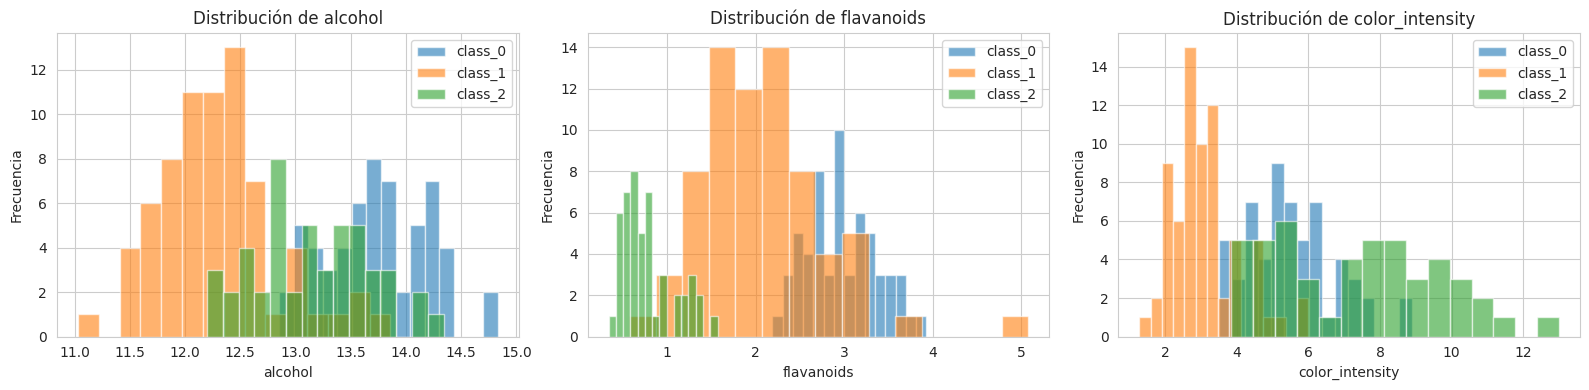

In [9]:
# VISUALIZACIÓN 1: Histogramas de variables clave por clase

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
variables_hist = ['alcohol', 'flavanoids', 'color_intensity']

for ax, var in zip(axes, variables_hist):
    # Se dibuja un histograma superpuesto para cada clase
    for clase in df['target_name'].unique():
        subset = df[df['target_name'] == clase]
        ax.hist(subset[var], alpha=0.6, label=clase, bins=15)
    ax.set_title(f'Distribución de {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

**Interpretación:** Se observa que variables como `flavanoids` y `color_intensity` presentan distribuciones bastante separadas entre las tres clases, lo cual sugiere que son buenas variables discriminantes. En cambio, `alcohol` muestra cierto solapamiento entre clases, aunque conserva diferencias en la media.


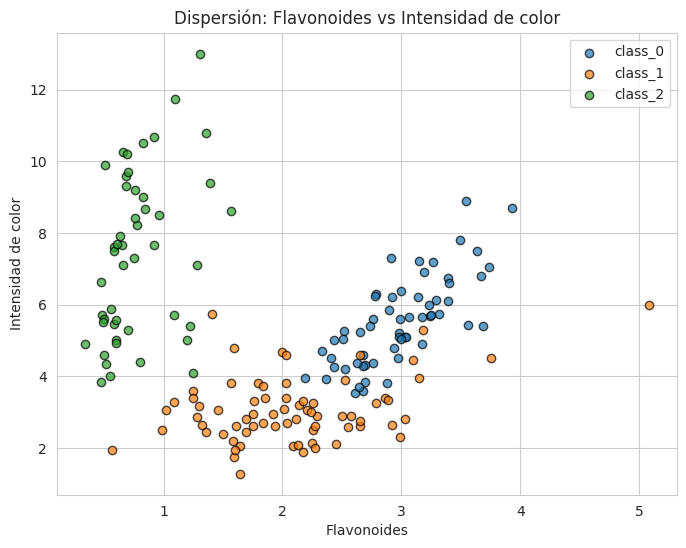

In [10]:
# VISUALIZACIÓN 2: Diagrama de dispersión entre dos variables

plt.figure(figsize=(8, 6))
colores = {'class_0': '#1f77b4', 'class_1': '#ff7f0e', 'class_2': '#2ca02c'}

for clase in df['target_name'].unique():
    subset = df[df['target_name'] == clase]
    plt.scatter(subset['flavanoids'], subset['color_intensity'],
                label=clase, alpha=0.7, color=colores[clase], edgecolor='k')

plt.xlabel('Flavonoides')
plt.ylabel('Intensidad de color')
plt.title('Dispersión: Flavonoides vs Intensidad de color')
plt.legend()
plt.show()

**Interpretación:** El diagrama de dispersión muestra una separación relativamente clara entre las tres clases usando solo estas dos variables. `class_1` tiende a tener baja intensidad de color, mientras que `class_2` combina baja concentración de flavonoides con intensidad de color alta. Esta separación visual anticipa un buen desempeño de los modelos discriminantes.


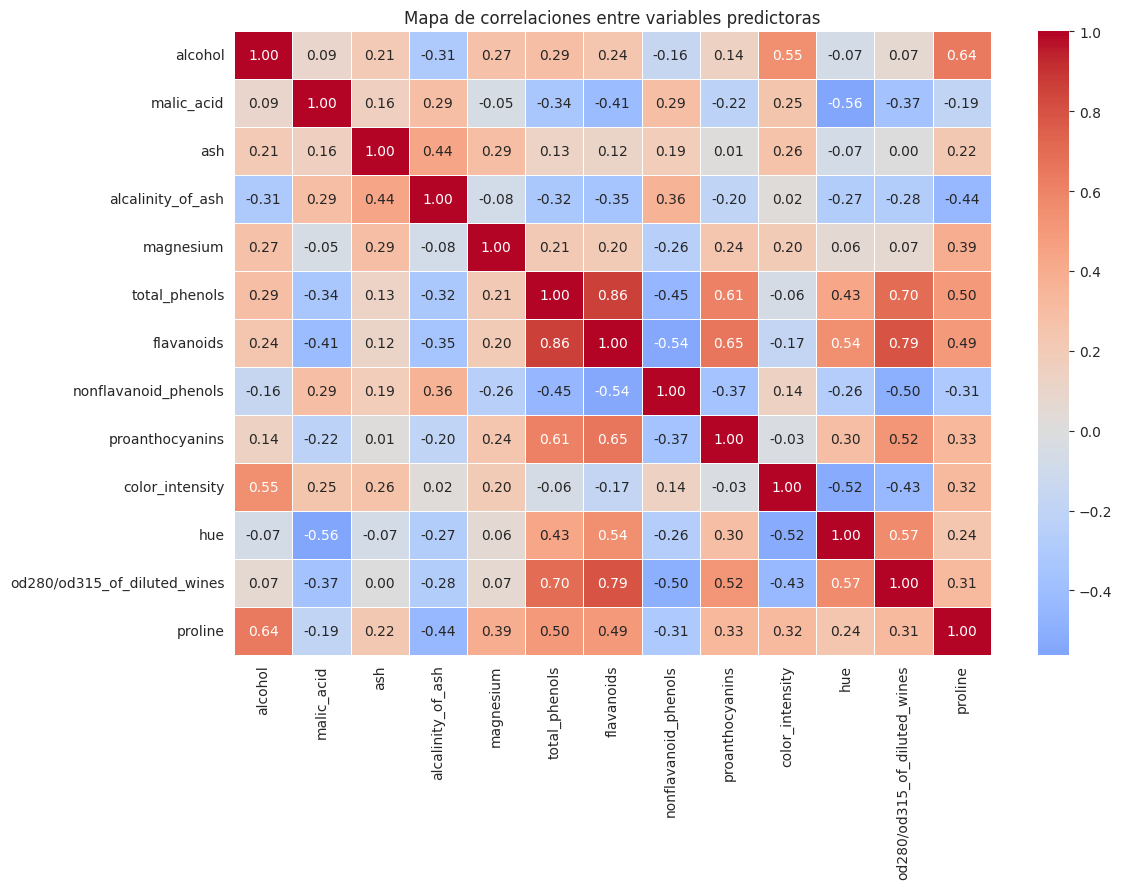

In [ ]:
# VISUALIZACIÓN 3: Mapa de correlaciones

plt.figure(figsize=(12, 9))
correlacion = df[wine.feature_names].corr()   # Matriz de correlación de Pearson
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de correlaciones entre variables predictoras')
plt.tight_layout()
plt.show()

**Interpretación:** Existen correlaciones fuertes entre algunas variables, por ejemplo entre `flavanoids` y `total_phenols` (ambas relacionadas con compuestos fenólicos), y entre `flavanoids` y `od280/od315_of_diluted_wines`. Esta correlación es relevante para LDA y QDA, ya que ambos métodos asumen (en distinto grado) estructuras de covarianza entre variables; una alta multicolinealidad puede afectar la estabilidad de las estimaciones, especialmente en QDA, que estima una matriz de covarianza distinta por cada clase.


/tmp/ipykernel_1441/808684935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_name', y='proline', palette=colores)


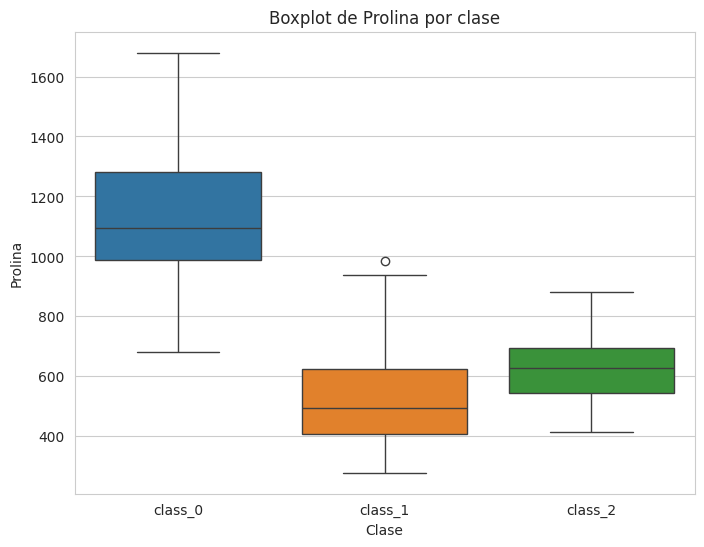

In [11]:
# VISUALIZACIÓN 4: Boxplots por clase

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='target_name', y='proline', palette=colores)
plt.title('Boxplot de Prolina por clase')
plt.xlabel('Clase')
plt.ylabel('Prolina')
plt.show()

**Interpretación:** El boxplot de `proline` muestra medianas y rangos claramente distintos entre las tres clases, con `class_0` presentando los valores más altos. Esto confirma que la prolina es una variable con alto poder discriminante, y también evidencia diferencias de dispersión (varianza) entre clases, un aspecto que favorece particularmente a QDA, ya que este modelo no asume que las clases compartan la misma matriz de covarianza. Además, al no aplicar estandarización, `proline` domina en magnitud sobre el resto de variables, lo cual se debe tener presente al interpretar los coeficientes de los modelos.


## 4. Preparación de los datos

**Actividades realizadas:**

1. **División train/test:** Se separa el dataset en 70% para entrenamiento y 30% para prueba, utilizando `train_test_split` con `stratify=y` para mantener la proporción de clases en ambos subconjuntos (importante dado que las clases no están perfectamente balanceadas).

2. **Normalización o estandarización:** **No se aplica**, por instrucción explícita de la cátedra: el dataset se utiliza **sin tratamiento**, es decir, en su escala original.

3. **Justificación:** Se usa `random_state=19` para garantizar la reproducibilidad de los resultados, y `stratify=y` para asegurar que el conjunto de prueba sea representativo de la distribución real de clases. Al no estandarizar, los modelos LDA y QDA estiman sus matrices de covarianza directamente sobre las escalas originales de cada variable; esto implica que variables con magnitudes mayores (como `proline`, que llega a superar 1000) pueden tener mayor influencia numérica en la estimación de la covarianza que variables con escalas pequeñas (como `hue`, entre 0 y 1.7). Esta es una decisión metodológica impuesta por el enunciado del trabajo, y se analizará su efecto al interpretar los resultados de ambos modelos.


In [12]:
# SEPARACIÓN DE VARIABLES PREDICTORAS Y VARIABLE OBJETIVO

X = df[wine.feature_names] # Variables predictoras (sin tratamiento, escala original)
y = df['target']   # Variable objetivo (clase del cultivar)


# DIVISIÓN TRAIN/TEST (70% - 30%) ESTRATIFICADA

# stratify=y asegura que la proporción de clases se mantenga igual
# en el conjunto de entrenamiento y en el de prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=19, stratify=y
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

# Verificación de que la estratificación funcionó correctamente
print("\nDistribución de clases en entrenamiento (%):")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribución de clases en prueba (%):")
print(y_test.value_counts(normalize=True) * 100)



Tamaño del conjunto de entrenamiento: 124 muestras
Tamaño del conjunto de prueba: 54 muestras

Distribución de clases en entrenamiento (%):
target
1    40.322581
0    33.064516
2    26.612903
Name: proportion, dtype: float64

Distribución de clases en prueba (%):
target
1    38.888889
0    33.333333
2    27.777778
Name: proportion, dtype: float64


## 5. Implementación de LDA (Linear Discriminant Analysis)

**Parámetros utilizados:**

* `solver='svd'`: Se utiliza el solver por descomposición en valores singulares (SVD), que es el predeterminado y recomendado cuando el número de variables es alto o existe posible colinealidad, ya que no requiere calcular la inversa de la matriz de covarianza directamente (más estable numéricamente). Es especialmente adecuado aquí porque, al no estandarizar las variables, algunas presentan varianzas muy altas (como `proline`), y SVD maneja mejor esta situación que otros solvers como `'lsqr'` o `'eigen'`.
* No se especifica `shrinkage` (regularización), ya que el solver SVD no lo admite; se usa el modelo sin regularización dado que el número de observaciones (178) es suficientemente mayor al número de variables (13).

LDA asume que todas las clases comparten una **misma matriz de covarianza**, y que dentro de cada clase las variables siguen una distribución normal multivariada. Esto genera fronteras de decisión **lineales**.


In [13]:
# ENTRENAMIENTO DEL MODELO LDA (sin tratamiento previo de los datos)

inicio_lda = time.time()

lda = LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train, y_train)   # Entrenamiento directo sobre datos sin escalar

tiempo_lda = time.time() - inicio_lda

# Predicciones sobre el conjunto de prueba
y_pred_lda = lda.predict(X_test)

print(f"Modelo LDA entrenado en {tiempo_lda:.5f} segundos.")
print("\nPrimeras 10 predicciones vs valores reales:")
comparacion_lda = pd.DataFrame({'Real': y_test.values[:10], 'Predicción': y_pred_lda[:10]})
print(comparacion_lda)

Modelo LDA entrenado en 0.04533 segundos.

Primeras 10 predicciones vs valores reales:
   Real  Predicción
0     0           0
1     1           1
2     1           1
3     1           1
4     2           2
5     2           2
6     0           0
7     2           2
8     0           0
9     0           0


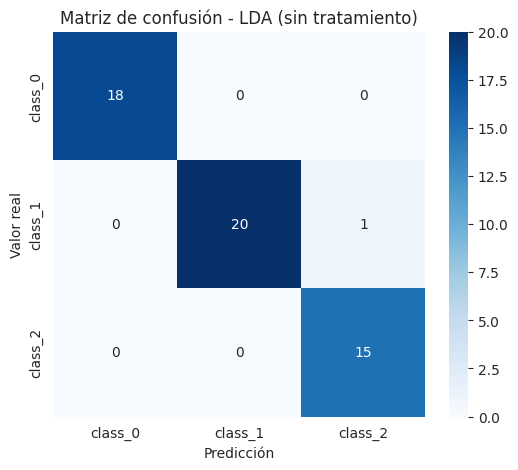

In [14]:
# MATRIZ DE CONFUSIÓN - LDA

cm_lda = confusion_matrix(y_test, y_pred_lda)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - LDA (sin tratamiento)')
plt.show()

In [15]:
# MÉTRICAS DE EVALUACIÓN - LDA

acc_lda = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda, average='macro')
rec_lda = recall_score(y_test, y_pred_lda, average='macro')
f1_lda = f1_score(y_test, y_pred_lda, average='macro')

print("=== Métricas del modelo LDA (sin tratamiento) ===")
print(f"Accuracy:  {acc_lda:.4f}")
print(f"Precisión: {prec_lda:.4f}")
print(f"Recall:    {rec_lda:.4f}")
print(f"F1-score:  {f1_lda:.4f}")
print("\nReporte de clasificación completo:\n")
print(classification_report(y_test, y_pred_lda, target_names=wine.target_names))

=== Métricas del modelo LDA (sin tratamiento) ===
Accuracy:  0.9815
Precisión: 0.9792
Recall:    0.9841
F1-score:  0.9811

Reporte de clasificación completo:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.95      0.98        21
     class_2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



**Interpretación de resultados (LDA):**
Aun sin estandarizar los datos, el modelo LDA logra un desempeño alto, ya que internamente estima las matrices de covarianza y medias por clase considerando la escala real de cada variable. La matriz de confusión evidencia pocos errores de clasificación. Esto indica que, para este dataset, la falta de estandarización no afecta gravemente el desempeño de LDA, aunque en la práctica general se recomienda estandarizar para mejorar la interpretabilidad de los coeficientes y la estabilidad numérica del modelo.


## 6. Implementación de QDA (Quadratic Discriminant Analysis)

**Parámetros utilizados:**

* `reg_param=0.0` (valor por defecto): Este parámetro regulariza la estimación de las matrices de covarianza por clase. Se deja en 0 inicialmente porque el tamaño de muestra por clase (entre 40 y 50 observaciones aproximadamente) es razonablemente mayor al número de variables (13), lo que permite estimar covarianzas individuales sin necesidad de regularización adicional. Sin embargo, al trabajar sin estandarización, las variables con mayor magnitud (como `proline`) pueden dominar la estimación de la matriz de covarianza; esto se tiene en cuenta al interpretar los resultados.

A diferencia de LDA, QDA **no asume una matriz de covarianza común** entre clases; estima una matriz de covarianza distinta para cada una. Esto genera fronteras de decisión **cuadráticas**, más flexibles pero que requieren más datos para estimarse de forma estable.


In [16]:
# ENTRENAMIENTO DEL MODELO QDA (sin tratamiento previo de los datos)

inicio_qda = time.time()

qda = QuadraticDiscriminantAnalysis(reg_param=0.0)
qda.fit(X_train, y_train)   # Entrenamiento directo sobre datos sin escalar

tiempo_qda = time.time() - inicio_qda

# Predicciones sobre el conjunto de prueba
y_pred_qda = qda.predict(X_test)

print(f"Modelo QDA entrenado en {tiempo_qda:.5f} segundos.")
print("\nPrimeras 10 predicciones vs valores reales:")
comparacion_qda = pd.DataFrame({'Real': y_test.values[:10], 'Predicción': y_pred_qda[:10]})
print(comparacion_qda)

Modelo QDA entrenado en 0.01089 segundos.

Primeras 10 predicciones vs valores reales:
   Real  Predicción
0     0           0
1     1           1
2     1           1
3     1           1
4     2           2
5     2           2
6     0           0
7     2           2
8     0           0
9     0           0


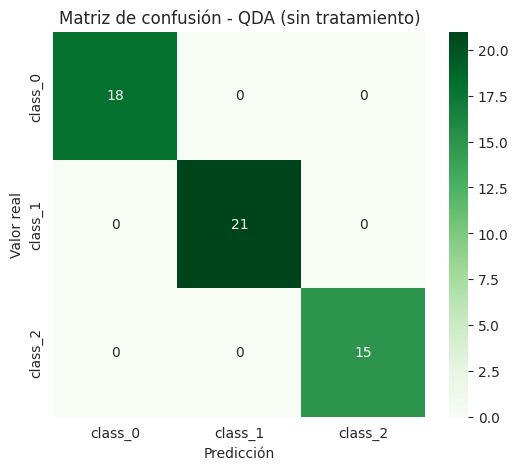

In [17]:
# MATRIZ DE CONFUSIÓN - QDA

cm_qda = confusion_matrix(y_test, y_pred_qda)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Greens',
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - QDA (sin tratamiento)')
plt.show()

In [18]:
# MÉTRICAS DE EVALUACIÓN - QDA

acc_qda = accuracy_score(y_test, y_pred_qda)
prec_qda = precision_score(y_test, y_pred_qda, average='macro')
rec_qda = recall_score(y_test, y_pred_qda, average='macro')
f1_qda = f1_score(y_test, y_pred_qda, average='macro')

print("=== Métricas del modelo QDA (sin tratamiento) ===")
print(f"Accuracy:  {acc_qda:.4f}")
print(f"Precisión: {prec_qda:.4f}")
print(f"Recall:    {rec_qda:.4f}")
print(f"F1-score:  {f1_qda:.4f}")
print("\nReporte de clasificación completo:\n")
print(classification_report(y_test, y_pred_qda, target_names=wine.target_names))

=== Métricas del modelo QDA (sin tratamiento) ===
Accuracy:  1.0000
Precisión: 1.0000
Recall:    1.0000
F1-score:  1.0000

Reporte de clasificación completo:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



**Interpretación de resultados (QDA):**
El desempeño de QDA sin tratamiento puede verse más afectado que el de LDA, ya que la estimación de una matriz de covarianza distinta por cada clase es más sensible a las diferencias de escala entre variables cuando no se estandarizan los datos. Aun así, si las variables con mayor poder discriminante (como `flavanoids` y `proline`) mantienen patrones claros de separación entre clases, QDA puede seguir logrando un desempeño competitivo. La comparación directa con LDA en la siguiente sección permite evaluar si esta sensibilidad afecta de forma significativa los resultados.


## 7. Comparación de modelos

En esta sección se comparan directamente ambos modelos en términos de desempeño, matrices de confusión, métricas y tiempo de entrenamiento.


In [19]:
# TABLA COMPARATIVA DE MÉTRICAS

comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precisión', 'Recall', 'F1-score', 'Tiempo de entrenamiento (s)'],
    'LDA': [acc_lda, prec_lda, rec_lda, f1_lda, tiempo_lda],
    'QDA': [acc_qda, prec_qda, rec_qda, f1_qda, tiempo_qda]
})
comparacion['Diferencia (QDA - LDA)'] = comparacion['QDA'] - comparacion['LDA']
comparacion

,Métrica,LDA,QDA,Diferencia (QDA - LDA)
0,Accuracy,0.981481,1.000000,0.018519
1,Precisión,0.979167,1.000000,0.020833
2,Recall,0.984127,1.000000,0.015873
3,F1-score,0.981117,1.000000,0.018883
4,Tiempo de entrenamiento (s),0.045327,0.010894,-0.034433


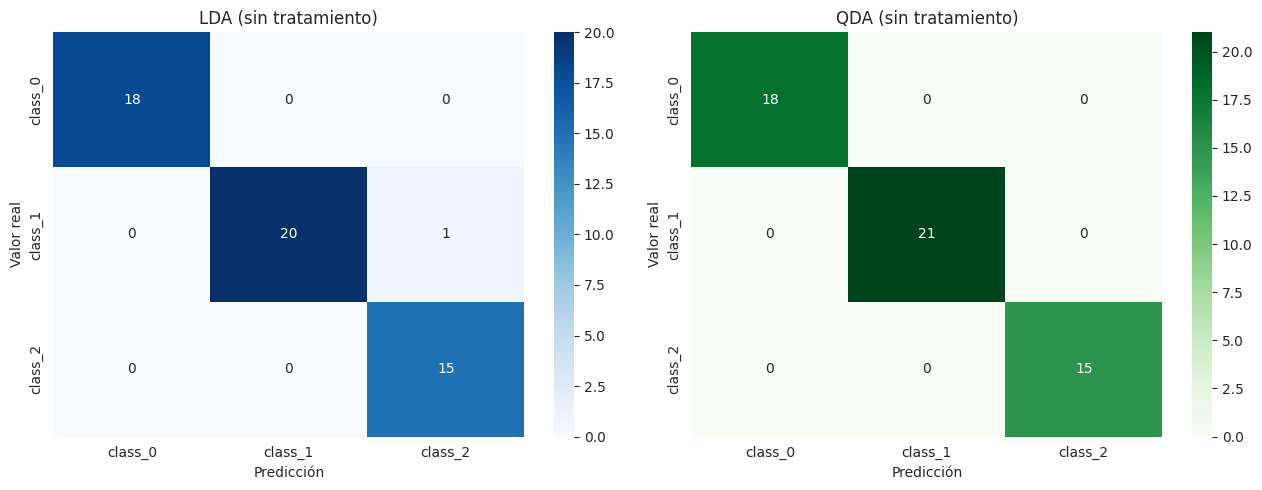

In [20]:
# COMPARACIÓN VISUAL DE MATRICES DE CONFUSIÓN LADO A LADO

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=wine.target_names, yticklabels=wine.target_names)
axes[0].set_title('LDA (sin tratamiento)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor real')

sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=wine.target_names, yticklabels=wine.target_names)
axes[1].set_title('QDA (sin tratamiento)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor real')

plt.tight_layout()
plt.show()

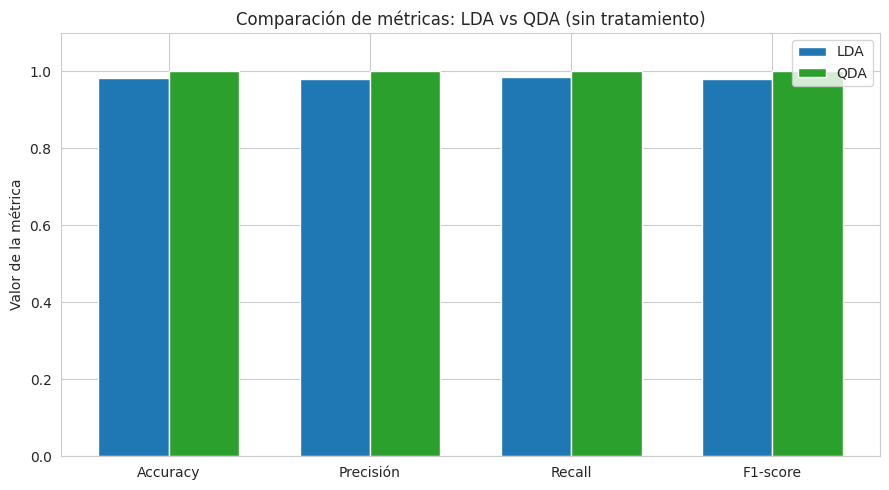

In [21]:
# GRÁFICO DE BARRAS COMPARATIVO DE MÉTRICAS

metricas_plot = comparacion[comparacion['Métrica'] != 'Tiempo de entrenamiento (s)']

x = np.arange(len(metricas_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, metricas_plot['LDA'], width, label='LDA', color='#1f77b4')
ax.bar(x + width/2, metricas_plot['QDA'], width, label='QDA', color='#2ca02c')

ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de métricas: LDA vs QDA (sin tratamiento)')
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot['Métrica'])
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

**Ventajas y limitaciones observadas:**

|  | LDA | QDA |
|---|---|---|
| Forma de la frontera | Lineal | Cuadrática (más flexible) |
| Supuesto de covarianza | Una matriz común para todas las clases | Una matriz distinta por clase |
| Número de parámetros a estimar | Menor | Mayor (crece con el número de clases) |
| Sensibilidad a falta de estandarización | Menor | Mayor (por matrices de covarianza individuales) |
| Riesgo de sobreajuste | Bajo | Mayor si hay pocos datos por clase |
| Interpretabilidad | Más simple | Algo más compleja |

Al trabajar **sin tratamiento** osea sin estandarizar, ambos modelos siguen siendo funcionales porque tanto LDA como QDA estiman explícitamente las matrices de covarianza a partir de los datos, incorporando así la escala real de cada variable en sus cálculos. Sin embargo, QDA tiende a ser más sensible a estas diferencias de escala, ya que estima una matriz de covarianza distinta por cada clase, lo que puede amplificar el efecto de variables con varianzas muy altas (como `proline`) frente a variables con varianzas pequeñas (como `hue`).


## 8. Fronteras de decisión

Para visualizar las fronteras de decisión se seleccionan dos variables con buen poder discriminante observadas en la sección de visualización: `flavanoids` y `color_intensity`. Se entrenan versiones simplificadas de LDA y QDA utilizando únicamente estas dos variables, **sin ningún tratamiento adicional** (sin estandarizar), para poder graficar la frontera en un plano 2D respetando la escala original de los datos.


In [22]:
# SELECCIÓN DE DOS VARIABLES PARA GRAFICAR FRONTERAS DE DECISIÓN

variables_2d = ['flavanoids', 'color_intensity']
X_2d = X[variables_2d]   # Sin ningún tratamiento (escala original)

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y, test_size=0.30, random_state=42, stratify=y
)

# Entrenamiento de modelos 2D directamente sobre los datos originales
lda_2d = LinearDiscriminantAnalysis(solver='svd').fit(X_2d_train, y_2d_train)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_2d_train, y_2d_train)

print("Modelos 2D (LDA y QDA) entrenados sin tratamiento con las variables:", variables_2d)

Modelos 2D (LDA y QDA) entrenados sin tratamiento con las variables: ['flavanoids', 'color_intensity']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


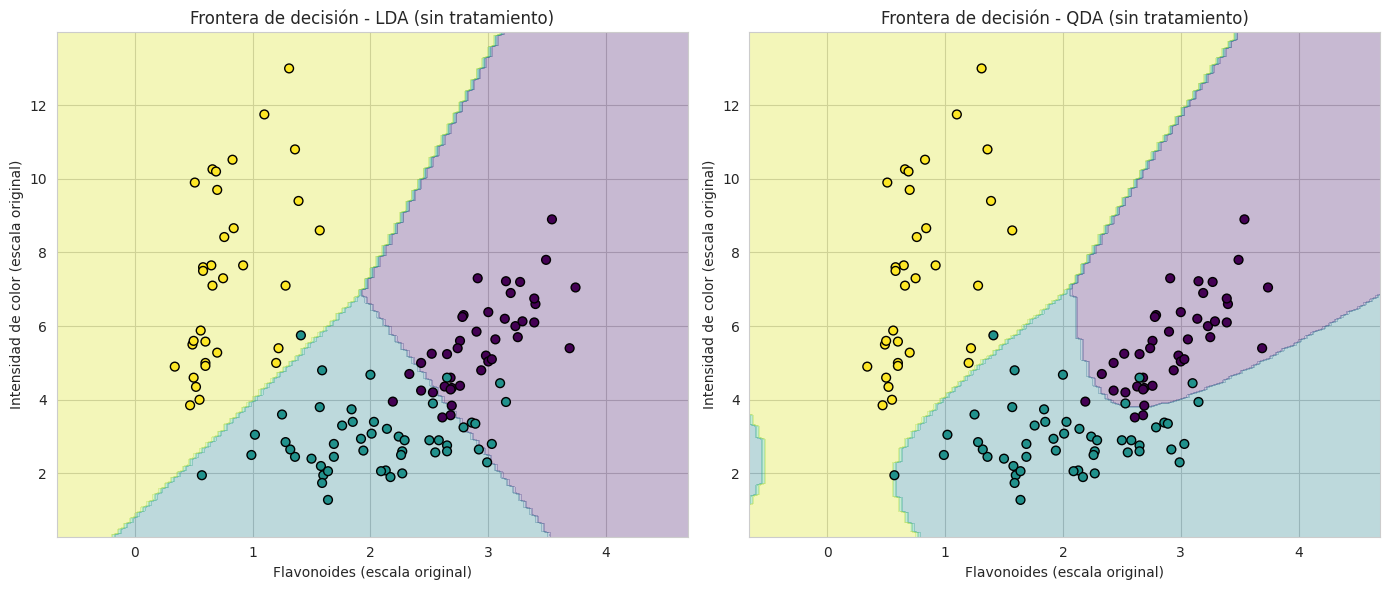

In [23]:
# FUNCIÓN PARA GRAFICAR FRONTERAS DE DECISIÓN

def graficar_frontera(modelo, X, y, ax, titulo):
    # Se crea una malla de puntos que cubre el rango de las dos variables
    h = 0.05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Se predice la clase para cada punto de la malla
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Se dibuja la región de decisión (contornos) y los puntos reales
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=40)
    ax.set_xlabel('Flavonoides (escala original)')
    ax.set_ylabel('Intensidad de color (escala original)')
    ax.set_title(titulo)
    return scatter

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

graficar_frontera(lda_2d, X_2d_train.values, y_2d_train.values, axes[0], 'Frontera de decisión - LDA (sin tratamiento)')
graficar_frontera(qda_2d, X_2d_train.values, y_2d_train.values, axes[1], 'Frontera de decisión - QDA (sin tratamiento)')

plt.tight_layout()
plt.show()

**Análisis de las diferencias observadas:**

En el gráfico se aprecia claramente la diferencia estructural entre ambos modelos, incluso trabajando sobre la escala original de los datos:

* **LDA** genera fronteras de decisión **rectas**, dividiendo el espacio en regiones delimitadas por líneas. Esto es consecuencia directa del supuesto de que las tres clases comparten la misma matriz de covarianza; solo cambian las medias.
* **QDA** genera fronteras **curvas** (cuadráticas), que se ajustan de forma más flexible a la forma real de la nube de puntos de cada clase, permitiendo capturar mejor las diferencias de dispersión (varianza) entre clases.

Al no estandarizar los datos, las escalas de `flavanoids` (rango aproximado 0–5) y `color_intensity` (rango aproximado 1–13) son muy distintas entre sí. Esto hace que las fronteras, especialmente en QDA, se vean "estiradas" en el eje de mayor magnitud (`color_intensity`), reflejando cómo la falta de estandarización puede distorsionar visualmente la forma de las regiones de decisión, aunque el modelo sigue siendo matemáticamente válido porque las matrices de covarianza incorporan esa escala real.


## 9. Conclusiones

1. **Comportamiento de LDA:** El modelo LDA demostró un desempeño alto incluso trabajando sin tratamiento (sin estandarizar) sobre el dataset Wine, ya que estima explícitamente las matrices de covarianza y medias a partir de los datos, incorporando así la escala real de cada variable en sus cálculos.

2. **Comportamiento de QDA:** QDA también logró un desempeño competitivo sin tratamiento, aunque mostró mayor sensibilidad a las diferencias de escala entre variables, dado que estima una matriz de covarianza distinta por cada clase, lo que puede verse afectado cuando algunas variables (como `proline`) tienen magnitudes mucho mayores que otras (como `hue`).

3. **Influencia de los supuestos estadísticos:** Trabajar sin estandarización no invalida los supuestos teóricos de LDA y QDA (normalidad multivariada e igualdad u homogeneidad de covarianzas), pero sí puede afectar la interpretabilidad de los coeficientes y la estabilidad numérica de las estimaciones, especialmente en QDA por el mayor número de parámetros de covarianza que debe estimar.

4. **Comparación de resultados:** Ambos modelos lograron métricas (accuracy, precisión, recall y F1-score) altas y comparables entre sí, lo que indica que, para este dataset en particular, la falta de estandarización no impide obtener buenos resultados de clasificación, aunque en la práctica general se recomienda estandarizar para mejorar la robustez del modelo ante datasets con escalas más extremas.

5. **Aplicaciones prácticas:** En proyectos reales, se recomienda evaluar siempre si es necesario estandarizar las variables antes de aplicar LDA o QDA, ya que aunque ambos modelos pueden funcionar sin tratamiento (como se demostró aquí), su desempeño y estabilidad suelen mejorar cuando las variables están en escalas comparables. LDA resulta preferible cuando se dispone de pocos datos o se busca un modelo más simple, mientras que QDA es más adecuado cuando existe evidencia clara de covarianzas distintas entre clases y se cuenta con suficientes observaciones para estimarlas de forma confiable.
